In [3]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#load data
df=pd.read_csv("application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
#type of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
#checking for missing values and there are lots of missing values
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [7]:
#top 10 missing values
missing=(df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print(missing.head(10))

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64


In [8]:
#checking for duplicates values
df.duplicated().sum()

np.int64(0)

In [9]:
#describe data
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [10]:
#all the columns
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [11]:
#one by one all the columns
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [12]:
#unique values in target

df["TARGET"].unique()

array([1, 0])

In [13]:
#in target column 0 means the person is not defaulter and 1 means the person is defaulter
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [14]:
#percentage of defaulter and non defaulter
df["TARGET"].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [15]:
#how many rows and columns
df.shape

(307511, 122)

In [16]:
#checking for missing values
df["TARGET"].value_counts(dropna=False)

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [17]:
#describe target column
df["TARGET"].describe()

count    307511.000000
mean          0.080729
std           0.272419
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: TARGET, dtype: float64

<Axes: xlabel='TARGET'>

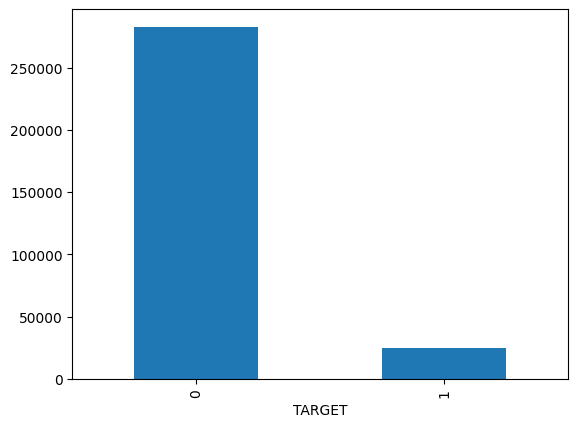

In [18]:
#plotting the target column
df["TARGET"].value_counts().plot(kind="bar")

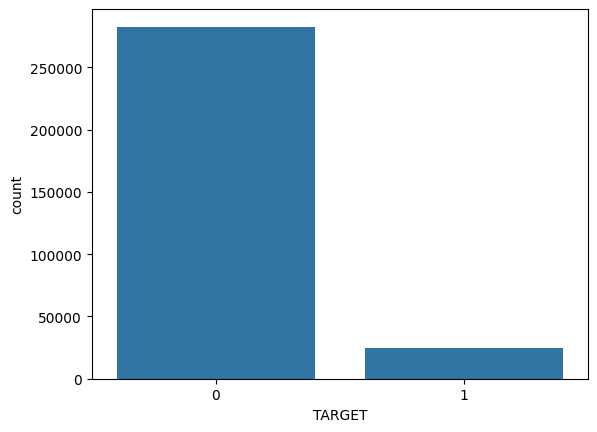

In [19]:
sns.countplot(x="TARGET",data=df)
plt.show()

In [20]:
df["NAME_CONTRACT_TYPE"].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

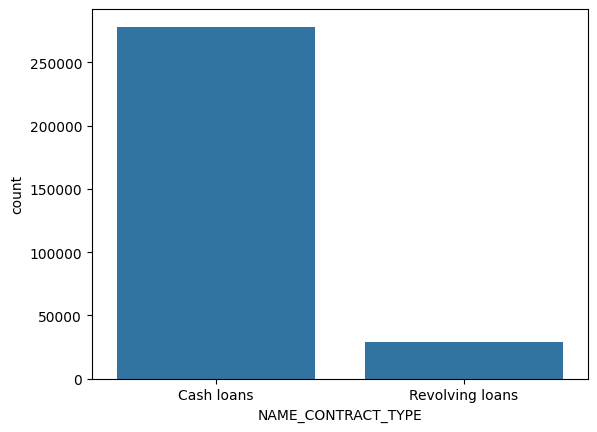

In [21]:
sns.countplot(x="NAME_CONTRACT_TYPE",data=df)
plt.show()

In [22]:
pd.crosstab(df["NAME_CONTRACT_TYPE"],df["TARGET"])

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,255011,23221
Revolving loans,27675,1604


In [23]:
"""categorical_columns=["CODE_GENDER","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE","OCCUPATION_TYPE","NAME_CONTRACT_TYPE","FLAG_OWN_CAR","FLAG_OWN_REALTY","FLAG_EMP_PHONE","FLAG_PHONE","FLAG_EMAIL","ORGANIZATION_TYPE"]
for col in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Columns : {col}")
    print('='*60)

    print(df[col].value_counts())

    plt.figure(figsize=(8,4))
    sns.countplot(y=col,data=df)
    plt.title(f"Counterplot : {col}")
    plt.tight_layout()
    plt.show()

    print(f"Relation with TARGET ")
    cross=pd.crosstab(df[col],df["TARGET"],normalize='index')[1]*100
    print(cross.round(2))


    cross.sort_values().plot(kind="barh",figsize=(6,4))
    plt.xlabel("Defaulter Rate")
    plt.title(f"{col} vs Default rate")
    plt.axvline(df["TARGET"].mean()*100,color='red',linestyle='--',label="overall avg")
    plt.legend()
    plt.show()"""

'categorical_columns=["CODE_GENDER","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS",\n"NAME_HOUSING_TYPE","OCCUPATION_TYPE","NAME_CONTRACT_TYPE","FLAG_OWN_CAR","FLAG_OWN_REALTY","FLAG_EMP_PHONE","FLAG_PHONE","FLAG_EMAIL","ORGANIZATION_TYPE"]\nfor col in categorical_columns:\n    print(f"\n{\'=\'*60}")\n    print(f"Columns : {col}")\n    print(\'=\'*60)\n\n    print(df[col].value_counts())\n\n    plt.figure(figsize=(8,4))\n    sns.countplot(y=col,data=df)\n    plt.title(f"Counterplot : {col}")\n    plt.tight_layout()\n    plt.show()\n\n    print(f"Relation with TARGET ")\n    cross=pd.crosstab(df[col],df["TARGET"],normalize=\'index\')[1]*100\n    print(cross.round(2))\n\n\n    cross.sort_values().plot(kind="barh",figsize=(6,4))\n    plt.xlabel("Defaulter Rate")\n    plt.title(f"{col} vs Default rate")\n    plt.axvline(df["TARGET"].mean()*100,color=\'red\',linestyle=\'--\',label="overall avg")\n    plt.legend()\n    plt.show()'

In [24]:
"""numerical_features=["CNT_CHILDREN","AMT_INCOME_TOTAL","DAYS_BIRTH","DAYS_EMPLOYED","CNT_FAM_MEMBERS","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","OWN_CAR_AGE",
"EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY","REGION_POPULATION_RELATIVE","DAYS_LAST_PHONE_CHANGE"]

for num in numerical_features:
    print(f"\n{'='*60}")
    print(f"Features : {num}")
    print("="*60)

    print(df[num].describe())

    plt.figure(figsize=(8,4))
    sns.histplot(df[num].dropna(),kde=True,bins=50)
    plt.title(f"Histogram : {num}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    sns.boxplot(x="TARGET",y=num,data=df)
    plt.title(f"{num} by TARGET")
    plt.show()
"""

'numerical_features=["CNT_CHILDREN","AMT_INCOME_TOTAL","DAYS_BIRTH","DAYS_EMPLOYED","CNT_FAM_MEMBERS","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","OWN_CAR_AGE",\n"EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY","REGION_POPULATION_RELATIVE","DAYS_LAST_PHONE_CHANGE"]\n\nfor num in numerical_features:\n    print(f"\n{\'=\'*60}")\n    print(f"Features : {num}")\n    print("="*60)\n\n    print(df[num].describe())\n\n    plt.figure(figsize=(8,4))\n    sns.histplot(df[num].dropna(),kde=True,bins=50)\n    plt.title(f"Histogram : {num}")\n    plt.tight_layout()\n    plt.show()\n\n    plt.figure(figsize=(8,4))\n    sns.boxplot(x="TARGET",y=num,data=df)\n    plt.title(f"{num} by TARGET")\n    plt.show()\n'

In [25]:
numerical_features=["CNT_CHILDREN","AMT_INCOME_TOTAL","DAYS_BIRTH","DAYS_EMPLOYED","CNT_FAM_MEMBERS","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","OWN_CAR_AGE",
"EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY","REGION_POPULATION_RELATIVE","DAYS_LAST_PHONE_CHANGE"]
comparison=df.groupby('TARGET')[numerical_features].mean().T
comparison.columns=["TARGET=0 (Repaid)","TARGET=1 (Default)"]
comparison["% Difference"]=((comparison["TARGET=1 (Default)"]-comparison["TARGET=0 (Repaid)"])/comparison["TARGET=0 (Repaid)"]*100).round(2)
print(comparison.sort_values('% Difference',key=abs,ascending=False))

                             TARGET=0 (Repaid)  TARGET=1 (Default)  \
DAYS_EMPLOYED                     65696.146123        42394.675448   
EXT_SOURCE_3                          0.520969            0.390717   
EXT_SOURCE_1                          0.511461            0.386968   
EXT_SOURCE_2                          0.523479            0.410935   
DAYS_LAST_PHONE_CHANGE             -976.388294         -808.796818   
OWN_CAR_AGE                          11.935540           13.668691   
CNT_CHILDREN                          0.412946            0.463807   
AMT_GOODS_PRICE                  542736.795003       488972.412554   
REGION_POPULATION_RELATIVE            0.021021            0.019131   
DAYS_BIRTH                       -16138.176397       -14884.828077   
AMT_CREDIT                       602648.282002       557778.527674   
REGION_RATING_CLIENT_W_CITY           2.022449            2.134824   
REGION_RATING_CLIENT                  2.043578            2.153635   
AMT_ANNUITY         

In [26]:
selected_features=["CODE_GENDER","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE","OCCUPATION_TYPE","FLAG_OWN_CAR","FLAG_OWN_REALTY",
"ORGANIZATION_TYPE","CNT_CHILDREN","CNT_FAM_MEMBERS","AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","DAYS_BIRTH","DAYS_EMPLOYED","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY",
"REGION_POPULATION_RELATIVE","EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","DAYS_LAST_PHONE_CHANGE","TARGET"]
df=df[selected_features]


In [27]:
df.head()

,CODE_GENDER,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,ORGANIZATION_TYPE,CNT_CHILDREN,...,DAYS_BIRTH,DAYS_EMPLOYED,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,REGION_POPULATION_RELATIVE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,TARGET
0,M,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,N,Y,Business Entity Type 3,0,...,-9461,-637,2,2,0.018801,0.083037,0.262949,0.139376,-1134.0,1
1,F,State servant,Higher education,Married,House / apartment,Core staff,N,N,School,0,...,-16765,-1188,1,1,0.003541,0.311267,0.622246,NaN,-828.0,0
2,M,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,Y,Y,Government,0,...,-19046,-225,2,2,0.010032,NaN,0.555912,0.729567,-815.0,0
3,F,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,N,Y,Business Entity Type 3,0,...,-19005,-3039,2,2,0.008019,NaN,0.650442,NaN,-617.0,0
4,M,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,N,Y,Religion,0,...,-19932,-3038,2,2,0.028663,NaN,0.322738,NaN,-1106.0,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   CODE_GENDER                  307511 non-null  object 
 1   NAME_INCOME_TYPE             307511 non-null  object 
 2   NAME_EDUCATION_TYPE          307511 non-null  object 
 3   NAME_FAMILY_STATUS           307511 non-null  object 
 4   NAME_HOUSING_TYPE            307511 non-null  object 
 5   OCCUPATION_TYPE              211120 non-null  object 
 6   FLAG_OWN_CAR                 307511 non-null  object 
 7   FLAG_OWN_REALTY              307511 non-null  object 
 8   ORGANIZATION_TYPE            307511 non-null  object 
 9   CNT_CHILDREN                 307511 non-null  int64  
 10  CNT_FAM_MEMBERS              307509 non-null  float64
 11  AMT_INCOME_TOTAL             307511 non-null  float64
 12  AMT_CREDIT                   307511 non-null  float64
 13 

In [29]:
X=df.drop("TARGET",axis=1)
y=df["TARGET"]

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [32]:
categorical=X.select_dtypes(include="object").columns
numerical=X.select_dtypes(exclude="object").columns

In [33]:
numerical_trans=Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_trans=Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

In [34]:
preprocessor=ColumnTransformer(transformers=[("num",numerical_trans,numerical),("cat",categorical_trans,categorical)])

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("classifier",LogisticRegression(class_weight="balanced",random_state=42,max_iter=1000))
    ]
)

In [37]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [38]:
y_pred=model.predict(X_test)

In [39]:
#logistic model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score
print("fi_score :",f1_score(y_test,y_pred))
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("confusion_matrix :",confusion_matrix(y_test,y_pred))
print("recall :",recall_score(y_test,y_pred))
print("precision :",precision_score(y_test,y_pred))


fi_score : 0.2591462236816689
accuracy_score : 0.6881940718338942
confusion_matrix : [[38972 17566]
 [ 1611  3354]]
recall : 0.6755287009063444
precision : 0.16032504780114723


In [40]:
from sklearn.ensemble import RandomForestClassifier
models=Pipeline(
                steps=[
                ("preprocessor",preprocessor),
                ("classifier",RandomForestClassifier(class_weight="balanced",random_state=42,n_estimators=50,max_depth=10,n_jobs=-1))
                ]
                )

In [41]:
models.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [42]:
y_pred_rf=models.predict(X_test)

In [43]:
y_prob_rf=models.predict_proba(X_test)[:,1]

In [44]:
#random_forest evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score,roc_auc_score
print("fi_score :",f1_score(y_test,y_pred_rf))
print("accuracy_score :",accuracy_score(y_test,y_pred_rf))
print("confusion_matrix :",confusion_matrix(y_test,y_pred_rf))
print("recall :",recall_score(y_test,y_pred_rf))
print("precision :",precision_score(y_test,y_pred_rf))
print("roc_auc :",roc_auc_score(y_test,y_prob_rf))

fi_score : 0.2633779264214047
accuracy_score : 0.7135099100856869
confusion_matrix : [[40733 15805]
 [ 1815  3150]]
recall : 0.6344410876132931
precision : 0.16618306515431286
roc_auc : 0.7378931126965842


In [45]:
from xgboost import XGBClassifier
model_xb=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("classifier",XGBClassifier(scale_pos_weight=11,random_state=42,n_estimators=100,max_depth=6,eval_metric="logloss",learning_rate=0.1))
    ]
)

In [46]:
model_xb.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [47]:
y_pred_xb=model_xb.predict(X_test)

In [48]:
y_prob_xb=model_xb.predict_proba(X_test)[:,1]

In [49]:
#XGB  evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score,roc_auc_score
print("fi_score :",f1_score(y_test,y_pred_xb))
print("accuracy_score :",accuracy_score(y_test,y_pred_xb))
print("confusion_matrix :",confusion_matrix(y_test,y_pred_xb))
print("recall :",recall_score(y_test,y_pred_xb))
print("precision :",precision_score(y_test,y_pred_xb))
print("roc_auc :",roc_auc_score(y_test,y_prob_xb))

fi_score : 0.27055237777128305
accuracy_score : 0.715932556135473
confusion_matrix : [[40792 15746]
 [ 1725  3240]]
recall : 0.6525679758308157
precision : 0.17065205941219846
roc_auc : 0.7544357907097177


In [58]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

param_dist={
    "classifier__n_estimators":[100,200,300,500],
    "classifier__max_depth":[3,5,7,9],
    "classifier__learning_rate":[0.01,0.05,0.1,0.2],
    "classifier__subsample":[0.6,0.8,1.0],
    "classifier__colsample_bytree":[0.6,0.8,1.0],
    "classifier__scale_pos_weight":[1,3,5],
    "classifier__gamma":[0,0.1,0.3,0.5]
}
random_search=RandomizedSearchCV(estimator=model_xb,param_distributions=param_dist,n_iter=20,scoring="f1",cv=3,verbose=2,random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
print("Best Parameters")
print(random_search.best_params_)

print("Best cv F1:")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters
{'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 5, 'classifier__n_estimators': 500, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.2, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.6}
Best cv F1:
0.2980518862129197


In [59]:
best_model=random_search.best_estimator_
y_pred_hp=best_model.predict(X_test)
y_prob_hp=best_model.predict_proba(X_test)[:,1]
print("fi_score :",f1_score(y_test,y_pred_hp))
print("accuracy_score :",accuracy_score(y_test,y_pred_hp))
print("confusion_matrix :",confusion_matrix(y_test,y_pred_hp))
print("recall :",recall_score(y_test,y_pred_hp))
print("precision :",precision_score(y_test,y_pred_hp))
print("roc_auc :",roc_auc_score(y_test,y_prob_hp))


fi_score : 0.30210420841683366
accuracy_score : 0.8641041900395102
confusion_matrix : [[51336  5202]
 [ 3156  1809]]
recall : 0.36435045317220544
precision : 0.25802310654685495
roc_auc : 0.7549968139849939


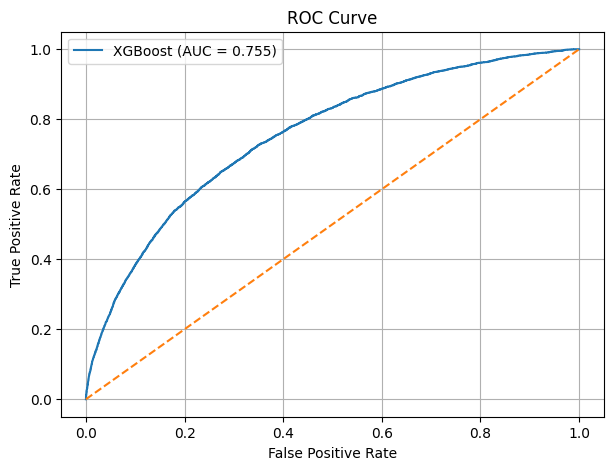

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_hp)
auc = roc_auc_score(y_test, y_prob_hp)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

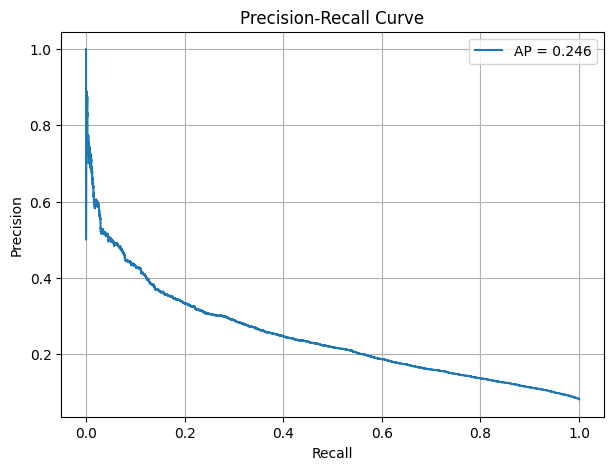

In [61]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_hp)
ap = average_precision_score(y_test, y_prob_hp)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
import pandas as pd
xgb_model=model_xb.named_steps["classifier"]
feature_names=model_xb.named_steps["preprocessor"].get_feature_names_out()
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
13,num__EXT_SOURCE_3,0.070030
12,num__EXT_SOURCE_2,0.055736
27,cat__NAME_EDUCATION_TYPE_Higher education,0.037590
15,cat__CODE_GENDER_F,0.033316
16,cat__CODE_GENDER_M,0.030490
21,cat__NAME_INCOME_TYPE_Pensioner,0.029395
25,cat__NAME_INCOME_TYPE_Working,0.025882
11,num__EXT_SOURCE_1,0.021137
61,cat__FLAG_OWN_CAR_N,0.021025
30,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.017844


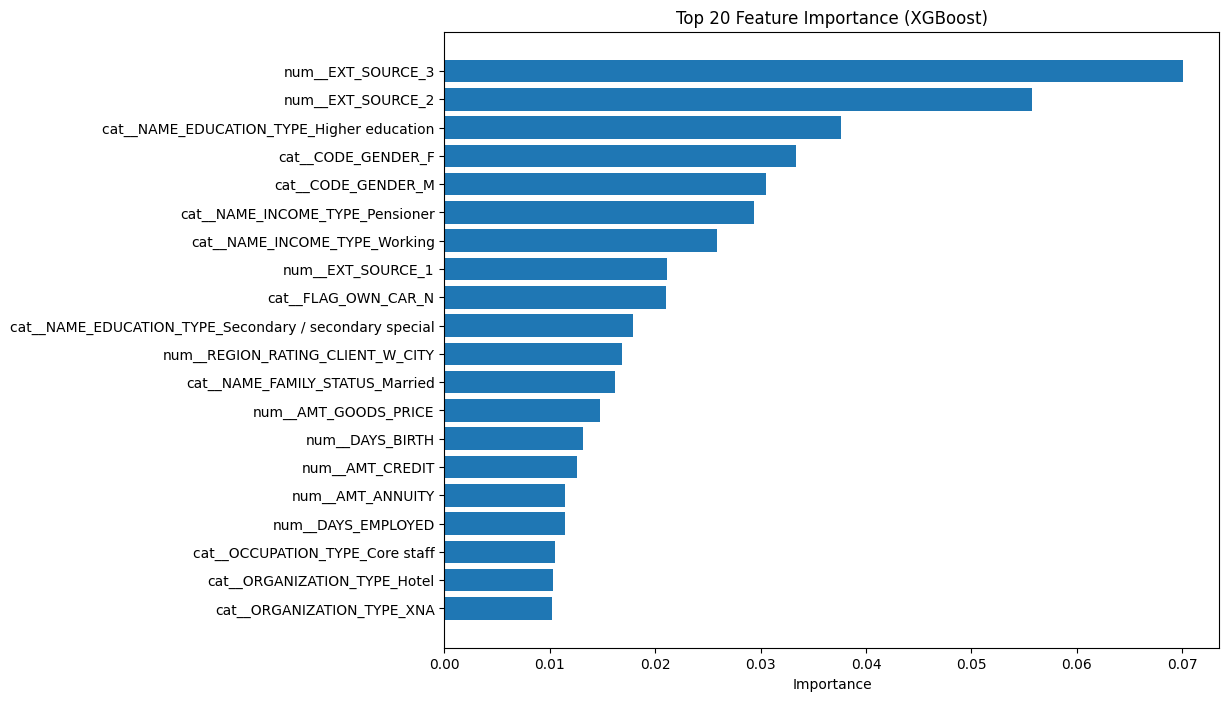

In [64]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 20 Feature Importance (XGBoost)")

plt.show()

In [65]:
!pip install shap


[notice] A new release of pip is available: 26.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


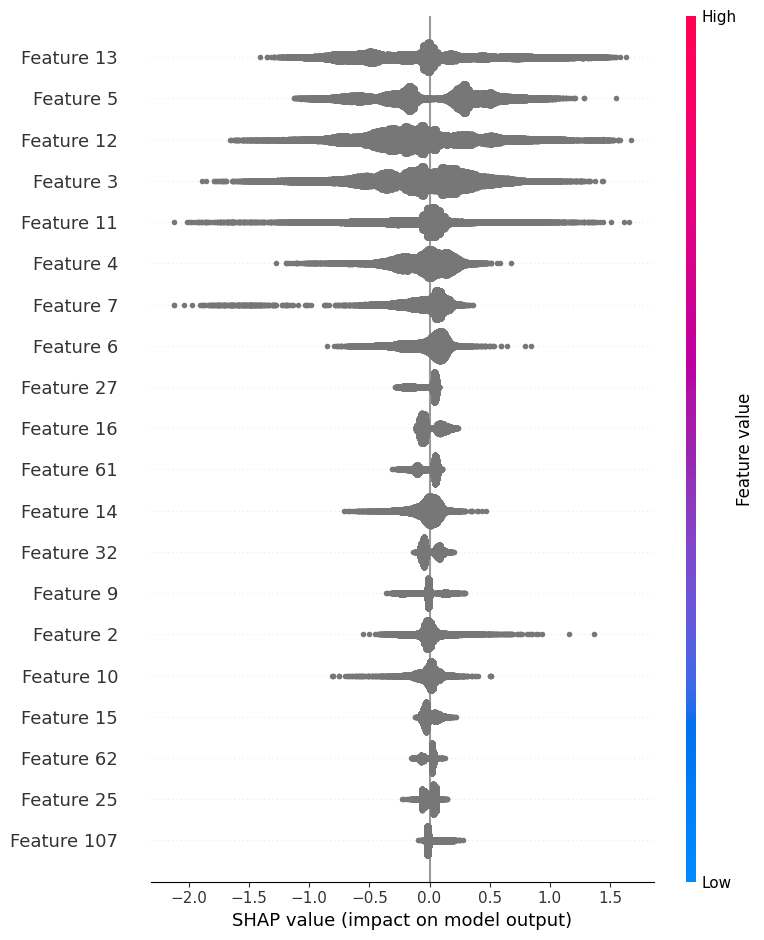

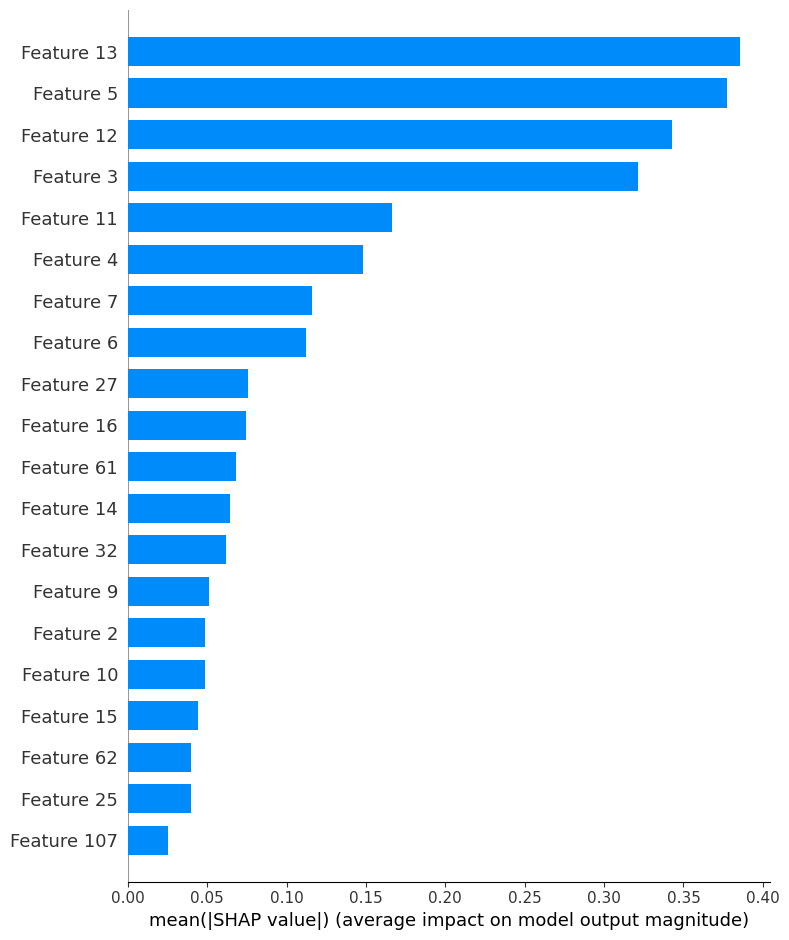

In [68]:
import shap
import pandas as pd

preprocessor = best_model.named_steps["preprocessor"]
classifier=best_model.named_steps["classifier"]

# Test data transform karo
X_test_transformed = preprocessor.transform(X_test)

# Feature names nikalo
feature_names = preprocessor.get_feature_names_out()

# SHAP Explainer
explainer = shap.TreeExplainer(classifier)
shap_values = explainer(X_test_transformed)

# Summary Plot
shap.summary_plot(shap_values, X_test_transformed)

# Bar Plot
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar")

In [73]:
import joblib
import os
os.makedirs("models",exist_ok=True)
# Save final pipeline (preprocessor + tuned XGBoost)
joblib.dump(best_model, "models/loan_risk_xgboost.pkl")

print("Model saved successfully!")

Model saved successfully!
